# Import libraries and read the dataset.

In [159]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.feature_selection import RFE, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

In [125]:
house = pd.read_csv("kc_house_data.csv")
house.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# Perform Exploratory Data Analysis. Find out how one variable related to other and distributions of data.

In [126]:
# Looking for nulls
print(house.isnull().any())

# Inspecting type
print(house.dtypes)

id               False
date             False
price            False
bedrooms         False
bathrooms        False
sqft_living      False
sqft_lot         False
floors           False
waterfront       False
view             False
condition        False
grade            False
sqft_above       False
sqft_basement    False
yr_built         False
yr_renovated     False
zipcode          False
lat              False
long             False
sqft_living15    False
sqft_lot15       False
dtype: bool
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_

# The data is pretty clean. There are no nulls which we need to treat and most of the features are in numeric format. 

# We shall drop the "id" and "date" columns as these 2 features will not be used in this analysis.

In [127]:
# Dropping the id and date columns
house = house.drop(['id', 'date'],axis=1)

# Pairplot Visualisation

# Let's create some Seaborn pairplots for the features ('sqft_lot','sqft_above','price','sqft_living','bedrooms') to get a feel for how the various features are distributed vis-a-vis the price as well as the number of bedrooms

C:\Anaconda\lib\site-packages\seaborn\axisgrid.py:2065: UserWarning: The `size` parameter has been renamed to `height`; pleaes update your code.
  warnings.warn(msg, UserWarning)
C:\Anaconda\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\Anaconda\lib\site-packages\numpy\core\_methods.py:140: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
C:\Anaconda\lib\site-packages\numpy\core\_methods.py:132: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
C:\Anaconda\lib\site-packages\statsmodels\nonparametric\bandwidths.py:20: RuntimeWarning: invalid value encountered in minimum
  return np

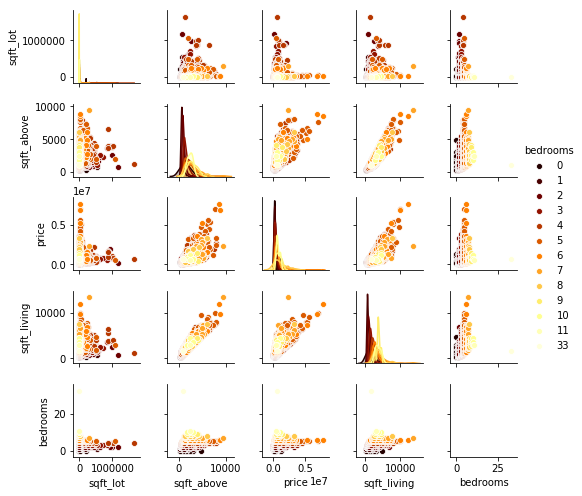

In [128]:
sns.pairplot(house[['sqft_lot','sqft_above','price','sqft_living','bedrooms']], hue='bedrooms', palette='afmhot',size=1.4)

# From the pairplots, we seem to get the classical linear distribution of the data points, for example with price against sqft_living. 

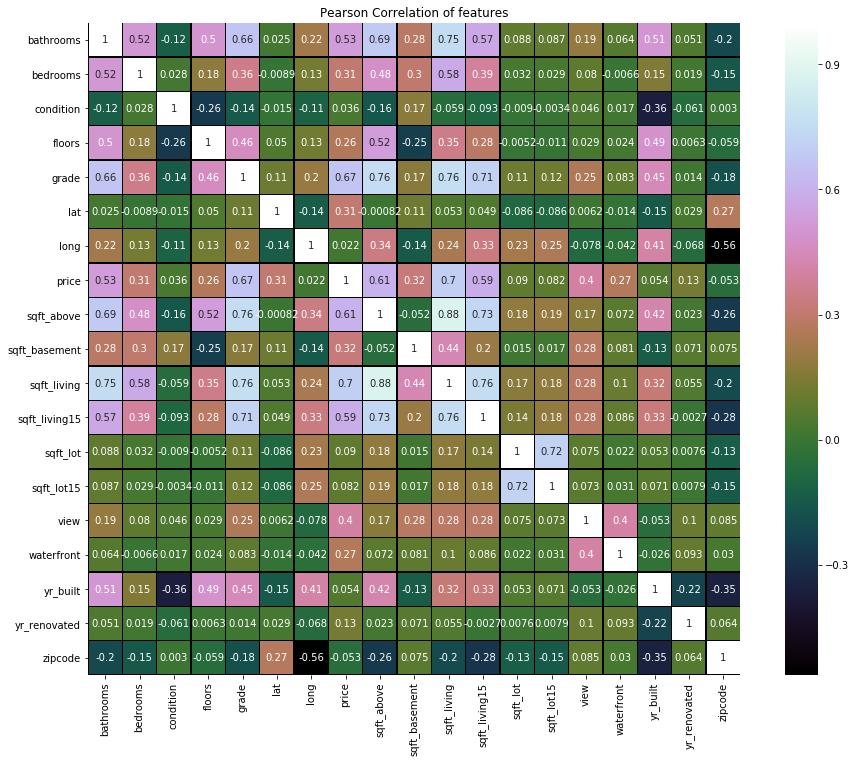

In [129]:
str_list = [] # empty list to contain columns with strings (words)

for colname, colvalue in house.iteritems():
    if type(colvalue[1]) == str:
         str_list.append(colname)

            # Get to the numeric columns by inversion            
num_list = house.columns.difference(str_list) 


# Create Dataframe containing only numerical features
house_num = house[num_list]
f, ax = plt.subplots(figsize=(16, 12))
plt.title('Pearson Correlation of features')


# Draw the heatmap using seaborn
sns.heatmap(house_num.astype(float).corr(),linewidths=0.25,vmax=1.0, square=True, cmap="cubehelix", linecolor='k', annot=True)

# Build a linear regression model to predict the house prices

In [130]:
feature_cols = [ u'bedrooms', u'bathrooms', u'sqft_living',
       u'sqft_lot', u'floors', u'waterfront', u'view', u'condition', u'grade',
       u'sqft_above', u'sqft_basement', u'yr_built', u'yr_renovated']
x = house[feature_cols]
y = house["price"]

In [131]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, random_state=3)

In [132]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [133]:
accuracy = regressor.score(x_test, y_test)
"Accuracy: {}%".format(int(round(accuracy * 100)))

'Accuracy: 66%'

# Try to find out important features or create new features to improve the performance for your model.

In [134]:
# First extract the target variable which is our House prices
Y = house.price


In [135]:
# Drop price from the house dataframe and create a matrix out of the house data
house_new = house.drop(['price'], axis=1)
X = house_new


In [136]:
print(Y)

0         221900.0
1         538000.0
2         180000.0
3         604000.0
4         510000.0
5        1225000.0
6         257500.0
7         291850.0
8         229500.0
9         323000.0
10        662500.0
11        468000.0
12        310000.0
13        400000.0
14        530000.0
15        650000.0
16        395000.0
17        485000.0
18        189000.0
19        230000.0
20        385000.0
21       2000000.0
22        285000.0
23        252700.0
24        329000.0
25        233000.0
26        937000.0
27        667000.0
28        438000.0
29        719000.0
           ...    
21583     399950.0
21584     380000.0
21585     270000.0
21586     505000.0
21587     385000.0
21588     414500.0
21589     347500.0
21590    1222500.0
21591     572000.0
21592     475000.0
21593    1088000.0
21594     350000.0
21595     520000.0
21596     679950.0
21597    1575000.0
21598     541800.0
21599     810000.0
21600    1537000.0
21601     467000.0
21602     224000.0
21603     507250.0
21604     42

In [137]:
print(X)

       bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0             3       1.00         1180      5650     1.0           0     0   
1             3       2.25         2570      7242     2.0           0     0   
2             2       1.00          770     10000     1.0           0     0   
3             4       3.00         1960      5000     1.0           0     0   
4             3       2.00         1680      8080     1.0           0     0   
5             4       4.50         5420    101930     1.0           0     0   
6             3       2.25         1715      6819     2.0           0     0   
7             3       1.50         1060      9711     1.0           0     0   
8             3       1.00         1780      7470     1.0           0     0   
9             3       2.50         1890      6560     2.0           0     0   
10            3       2.50         3560      9796     1.0           0     0   
11            2       1.00         1160      6000   

In [138]:
X.shape

(21613, 18)

In [139]:
# Store the column/feature names into a list "colnames"
colnames = house_new.columns

In [140]:
print(colnames)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [141]:
# Define dictionary to store our rankings
ranks = {}
# Create our function which stores the feature rankings to the ranks dictionary
def ranking(ranks, names, order=1):
    minmax = MinMaxScaler()
    ranks = minmax.fit_transform(order*np.array([ranks]).T).T[0]
    ranks = map(lambda x: round(x,2), ranks)
    return dict(zip(names, ranks))

In [142]:
# Construct our Linear Regression model
lr = LinearRegression(normalize=True)
lr.fit(x,y)
#stop the search when only the last feature is left
rfe = RFE(lr, n_features_to_select=1, verbose =3 )
rfe.fit(x,y)
ranks["RFE"] = ranking(list(map(float, rfe.ranking_)), colnames, order=-1)

Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.


In [143]:
# Using Linear Regression
lr = LinearRegression(normalize=True)
lr.fit(x,y)
ranks["LinReg"] = ranking(np.abs(lr.coef_), colnames)

# Using Ridge 
ridge = Ridge(alpha = 7)
ridge.fit(x,y)
ranks['Ridge'] = ranking(np.abs(ridge.coef_), colnames)

# Using Lasso
lasso = Lasso(alpha=.05)
lasso.fit(x, y)
ranks["Lasso"] = ranking(np.abs(lasso.coef_), colnames)

C:\Anaconda\lib\site-packages\sklearn\linear_model\coordinate_descent.py:492: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Fitting data with very small alpha may cause precision problems.
  ConvergenceWarning)


In [146]:
# Put the mean scores into a Pandas dataframe
meanplot = pd.DataFrame(list(r.items()), columns= ['Feature','Mean Ranking'])

# Sort the dataframe
meanplot = meanplot.sort_values('Mean Ranking', ascending=False)

C:\Anaconda\lib\site-packages\seaborn\categorical.py:3666: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
C:\Anaconda\lib\site-packages\seaborn\categorical.py:3672: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


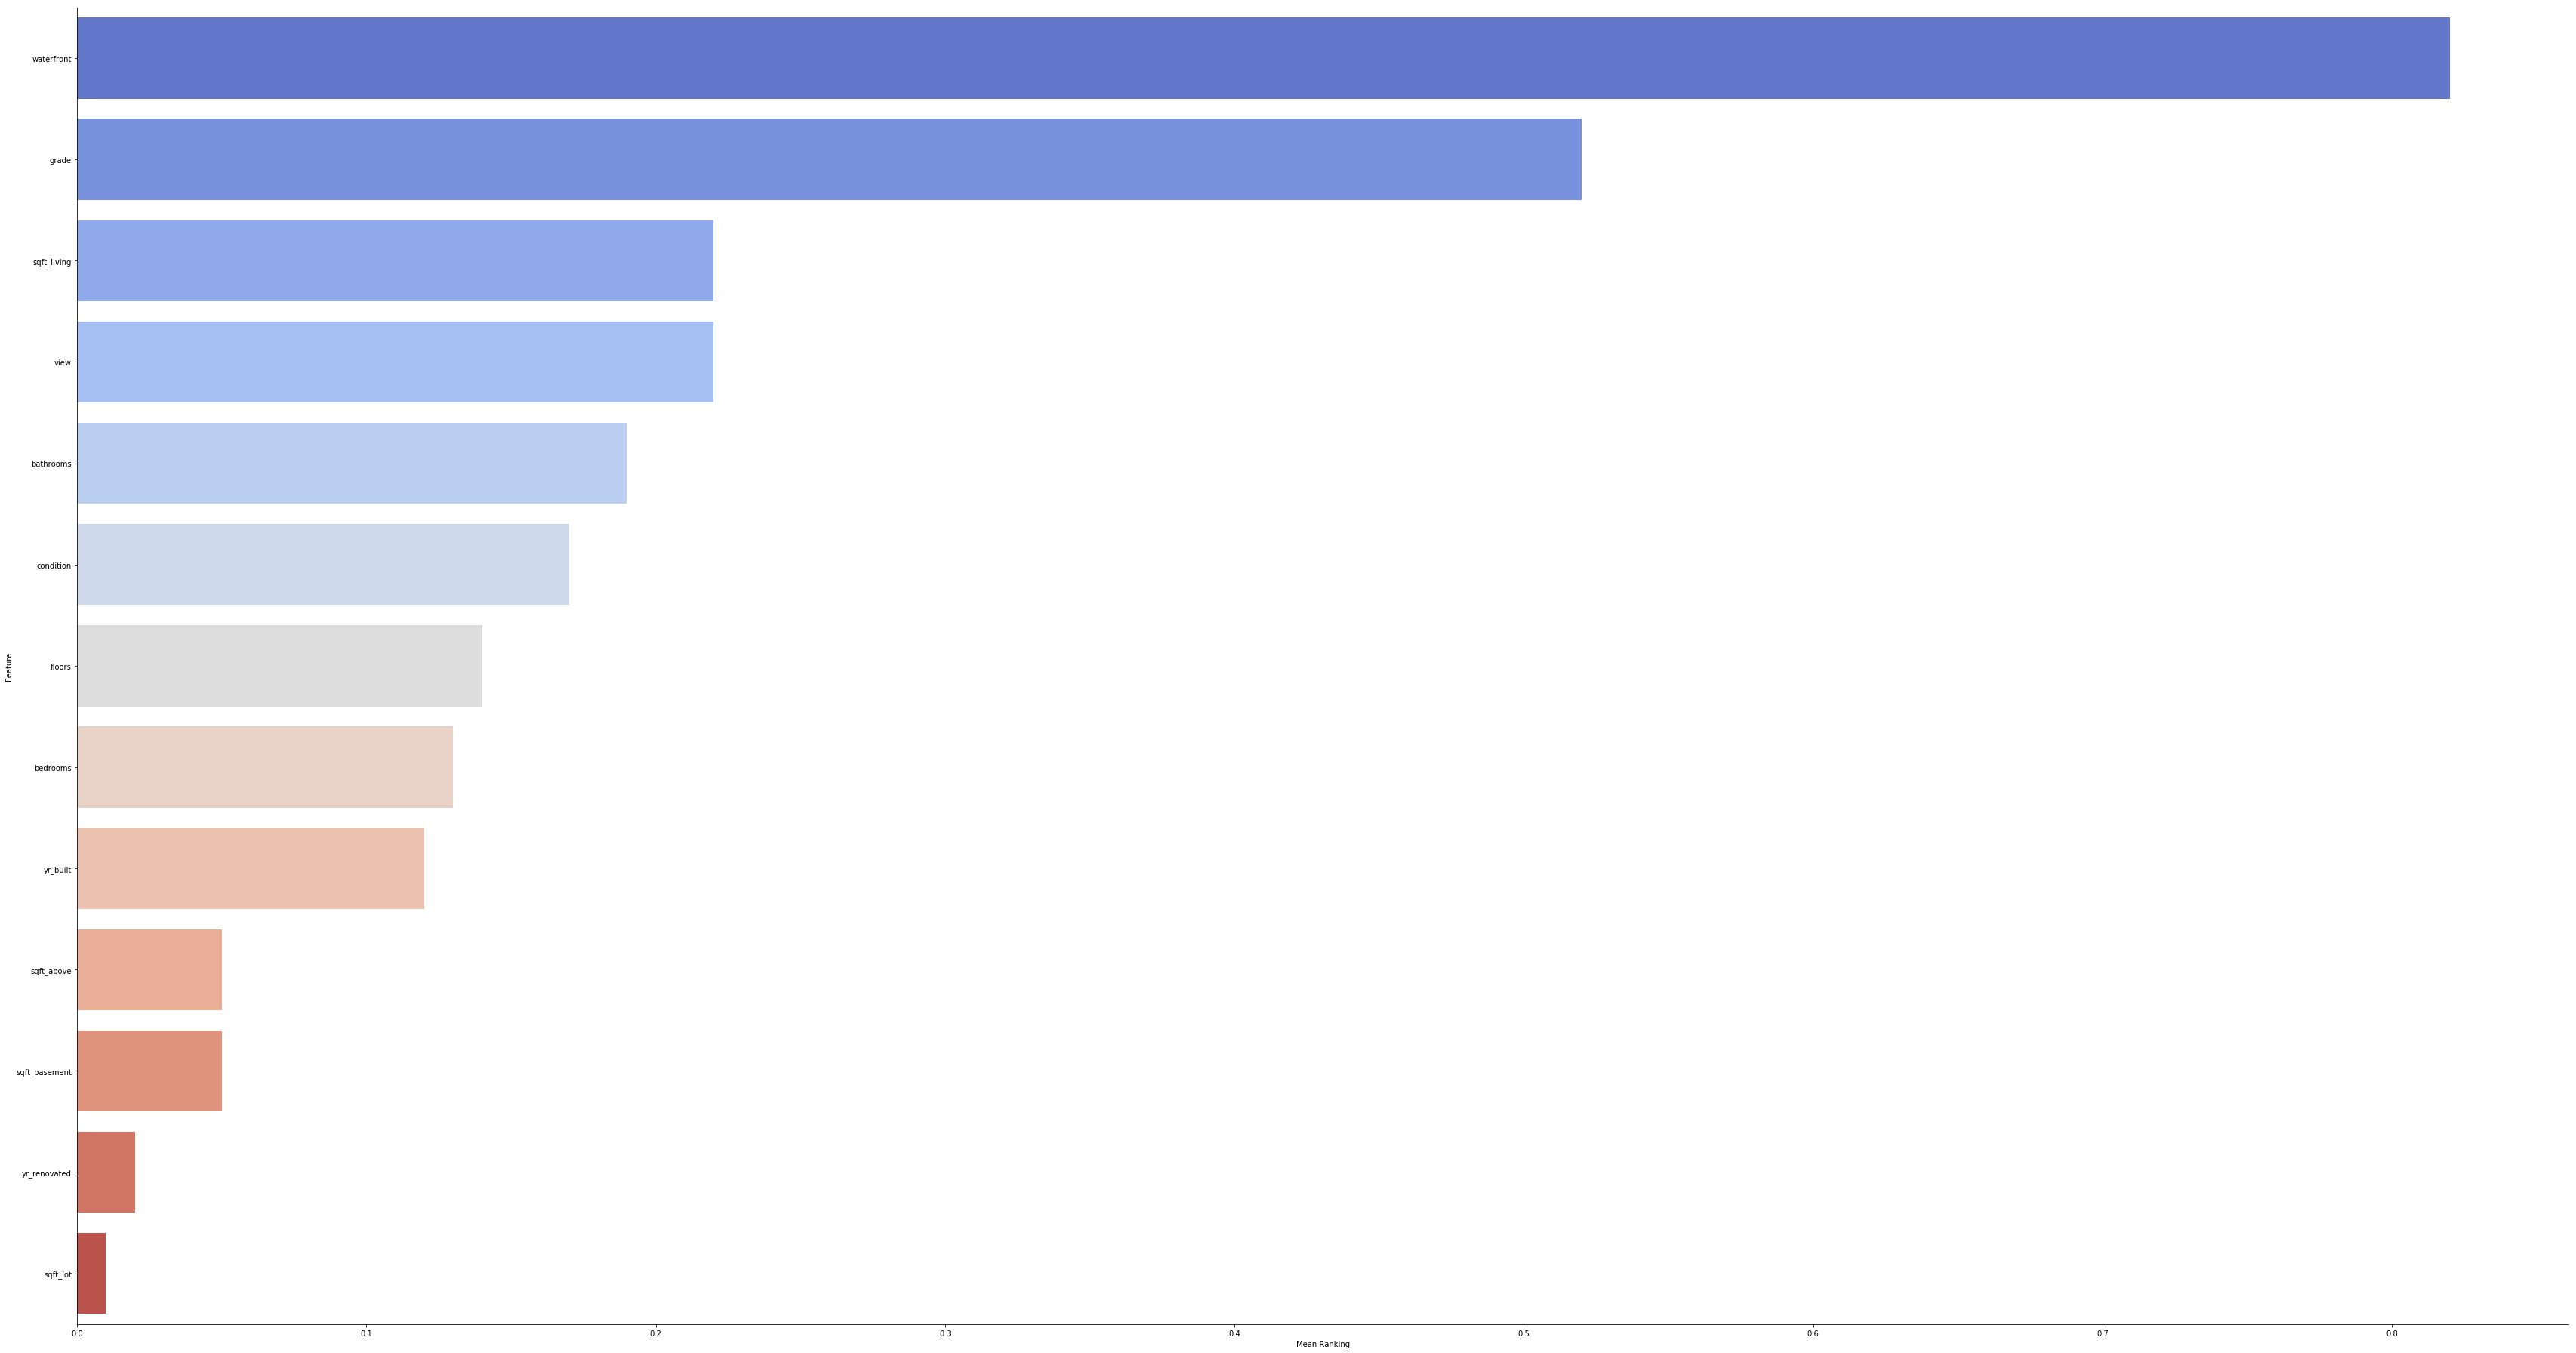

In [147]:
# Let's plot the ranking of the features
sns.factorplot(x="Mean Ranking", y="Feature", data = meanplot, kind="bar", 
               size=25, aspect=1.9, palette='coolwarm')

# We can see from the feature ranking that the top 3 features are 'lat', 'waterfront' and 'grade'. The bottom 3 are 'sqft_lot15', 'sqft_lot' and 'sqft_basement'. 

In [148]:
# Dropping the bottom three features

In [149]:
# First extract the target variable which is our House prices
Y_new = house.price

In [154]:
# Drop price along with the bottom three features from the house dataframe and create a matrix out of the house data
house_new = house.drop(['price'], axis=1)
house_new = house_new.drop(['sqft_lot15'], axis=1)
house_new = house_new.drop(['sqft_lot'], axis=1)
house_new = house_new.drop(['sqft_basement'], axis=1)


In [155]:
X_new = house_new


In [156]:
print(X_new)

       bedrooms  bathrooms  sqft_living  floors  waterfront  view  condition  \
0             3       1.00         1180     1.0           0     0          3   
1             3       2.25         2570     2.0           0     0          3   
2             2       1.00          770     1.0           0     0          3   
3             4       3.00         1960     1.0           0     0          5   
4             3       2.00         1680     1.0           0     0          3   
5             4       4.50         5420     1.0           0     0          3   
6             3       2.25         1715     2.0           0     0          3   
7             3       1.50         1060     1.0           0     0          3   
8             3       1.00         1780     1.0           0     0          3   
9             3       2.50         1890     2.0           0     0          3   
10            3       2.50         3560     1.0           0     0          3   
11            2       1.00         1160 

In [157]:
# Store the column/feature names into a list "colnames"
colnames = house_new.columns

# Use appropriate cross validations techniques to find out the best predictor parameters and best prediction.

In [160]:
model = LinearRegression()

scores = cross_val_score(model, X_new, Y_new, cv=10)
print("Cross-validation scores: {}".format(scores))
print("Average cross-validation score: {:.2f}".format(scores.mean()))

Cross-validation scores: [0.69530222 0.69783122 0.68801913 0.69158275 0.6803511  0.70379235
 0.71143325 0.70855822 0.7000962  0.6717659 ]
Average cross-validation score: 0.69
